# Daily Treasury Par Yield Curve Analysis

Fetches the US Treasury Daily Par Yield Curve XML feed, persists it to Postgres, bootstraps zero-coupon yields, derives forward rates, and plots the result.

All of the actual logic (fetch, parse, bootstrap, forwards, storage, plotting) lives in the `fred_lx` package -- see [docs/refactor-plan.md](../docs/refactor-plan.md). This notebook is just orchestration, so the same building blocks are reusable from other notebooks (e.g. PCA, risk simulation) without copy-paste.


In [1]:
import matplotlib.pyplot as plt

from fred_lx.curves.bootstrap import par_to_zero
from fred_lx.curves.forwards import forward_rates
from fred_lx.curves.par_curve import latest_curve
from fred_lx.ingestion.treasury_xml import fetch_treasury_xml, parse_par_yields
from fred_lx.storage.postgres_store import apply_schema, connect, upsert_par_yields
from fred_lx.viz.curves import plot_yield_curves
from fred_lx.viz.forwards import create_summary_table, plot_forward_rates


## Ingest: fetch the XML feed and persist it to Postgres

In [2]:
xml_data = fetch_treasury_xml()
history = parse_par_yields(xml_data)
print(f"Parsed {len(history)} dates, {history['date'].min()} to {history['date'].max()}")

conn = connect()
apply_schema(conn)
written = upsert_par_yields(conn, history, source="treasury_xml")
conn.close()
print(f"Upserted {written} (date, maturity) rows into Postgres")


Parsed 117 dates, 2026-01-02 to 2026-06-18
Upserted 1521 (date, maturity) rows into Postgres


## Bootstrap zero-coupon yields for the latest curve

In [3]:
curve = latest_curve(history)
print(f"Latest curve: {curve['date'].iloc[0]} ({len(curve)} maturities)")

curve_with_zero = par_to_zero(curve)
curve_with_zero[['maturity_label', 'par_yield', 'zero_coupon_yield']]


Latest curve: 2026-06-18 (13 maturities)


,maturity_label,par_yield,zero_coupon_yield
0,1M,3.69,3.690000
1,2M,3.74,3.740000
2,3M,3.83,3.830000
3,4M,3.85,3.850000
4,6M,3.92,3.920000
5,1Y,4.00,4.000000
6,2Y,4.19,4.194169
7,3Y,4.19,4.192588
8,5Y,4.23,4.235203
9,7Y,4.34,4.357169


## Implied forward rates

In [4]:
fwd = forward_rates(curve_with_zero)
fwd


,period,start_year,end_year,forward_rate,start_spot_rate,end_spot_rate
0,1Y-2Y,1,2,4.388700,4.000000,4.194169
1,2Y-3Y,2,3,4.189425,4.194169,4.192588
2,3Y-5Y,3,5,4.299158,4.192588,4.235203
3,5Y-7Y,5,7,4.662709,4.235203,4.357169
4,7Y-10Y,7,10,4.816637,4.357169,4.494797
5,10Y-20Y,10,20,5.677496,4.494797,5.084483
6,20Y-30Y,20,30,4.815056,5.084483,4.994597


## Visualizations

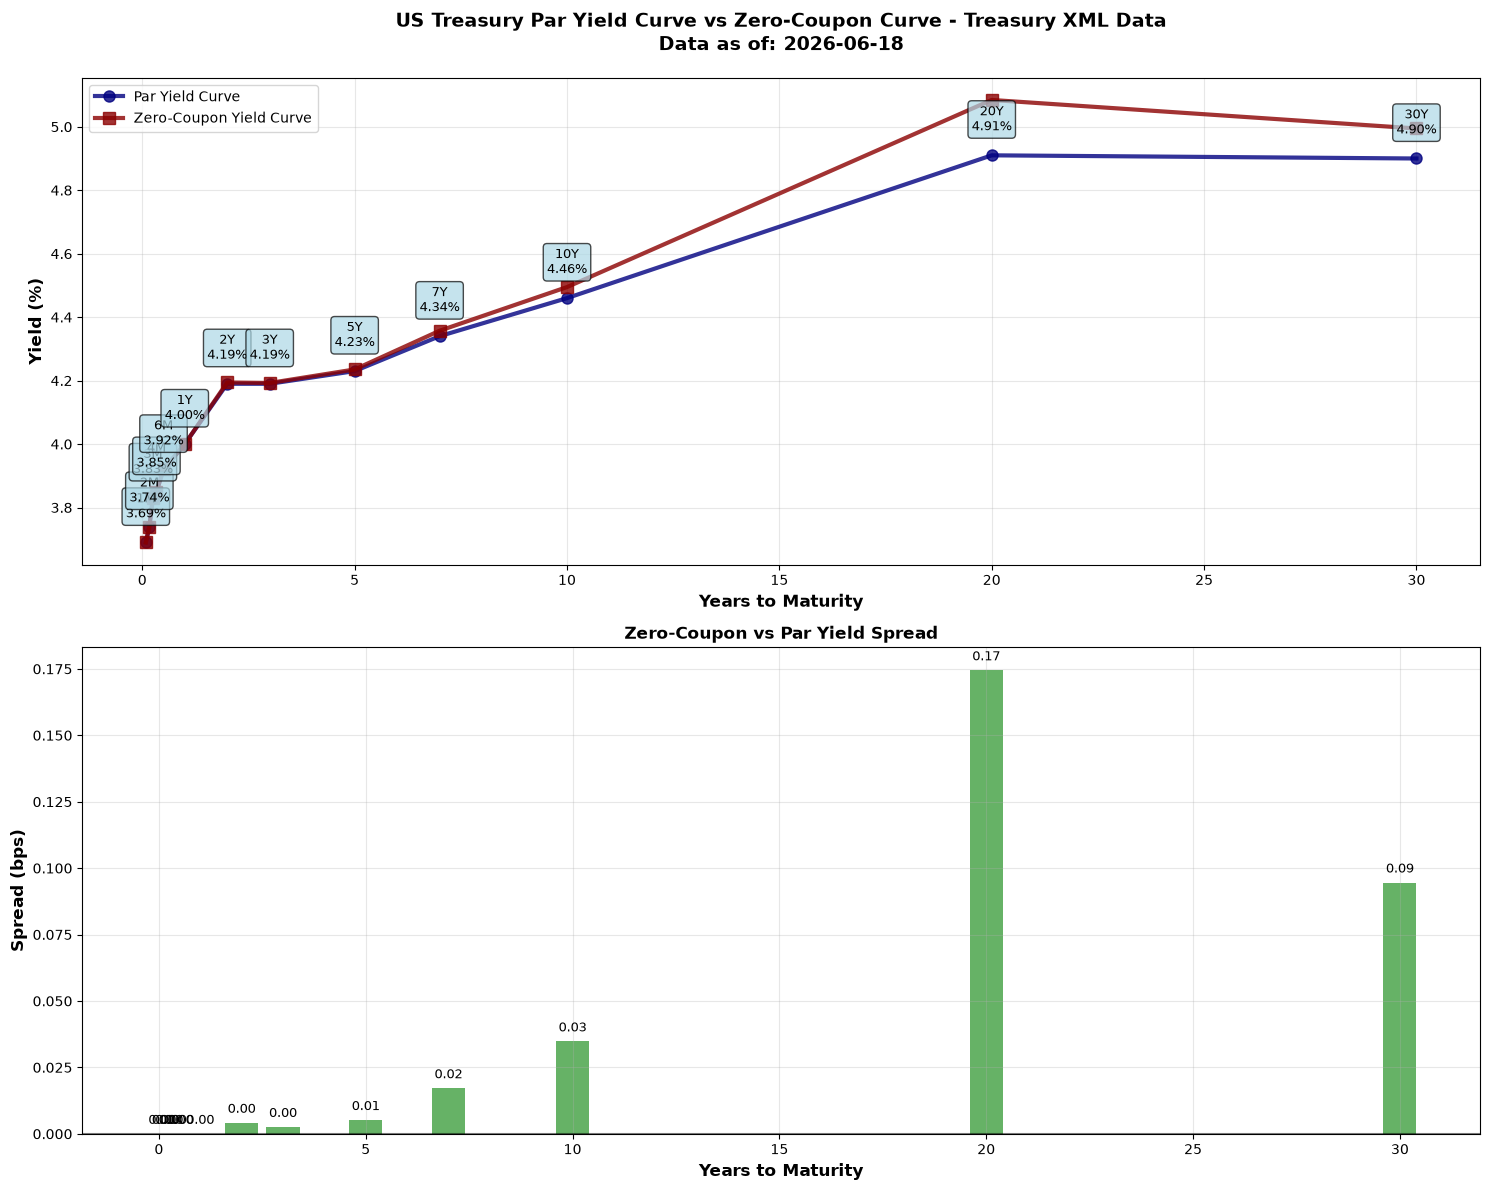

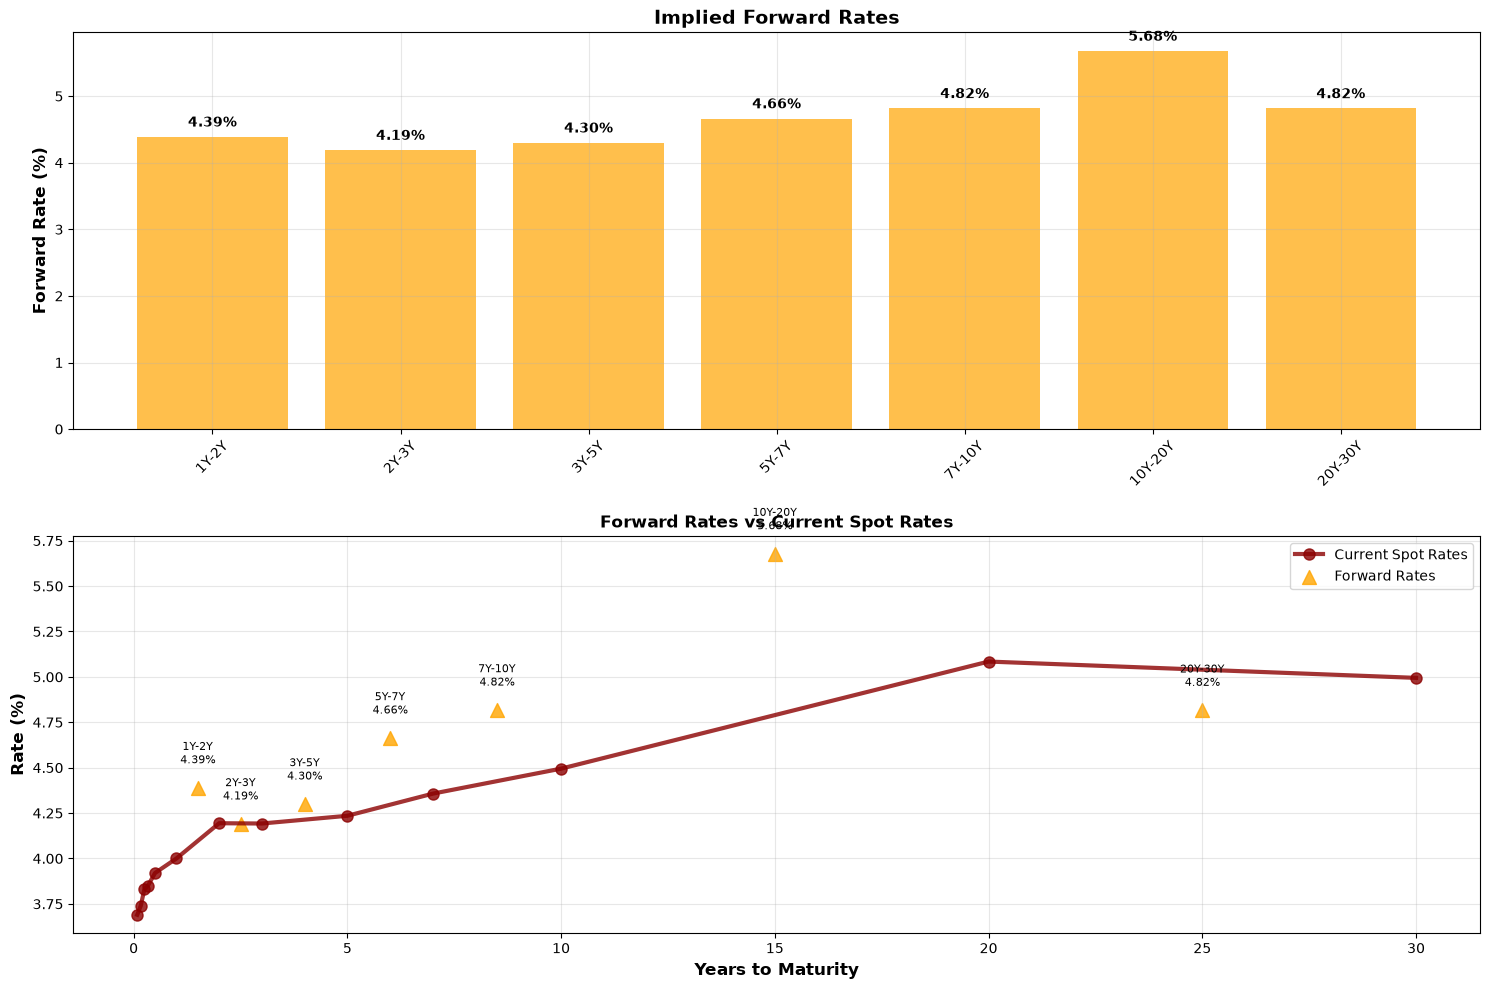

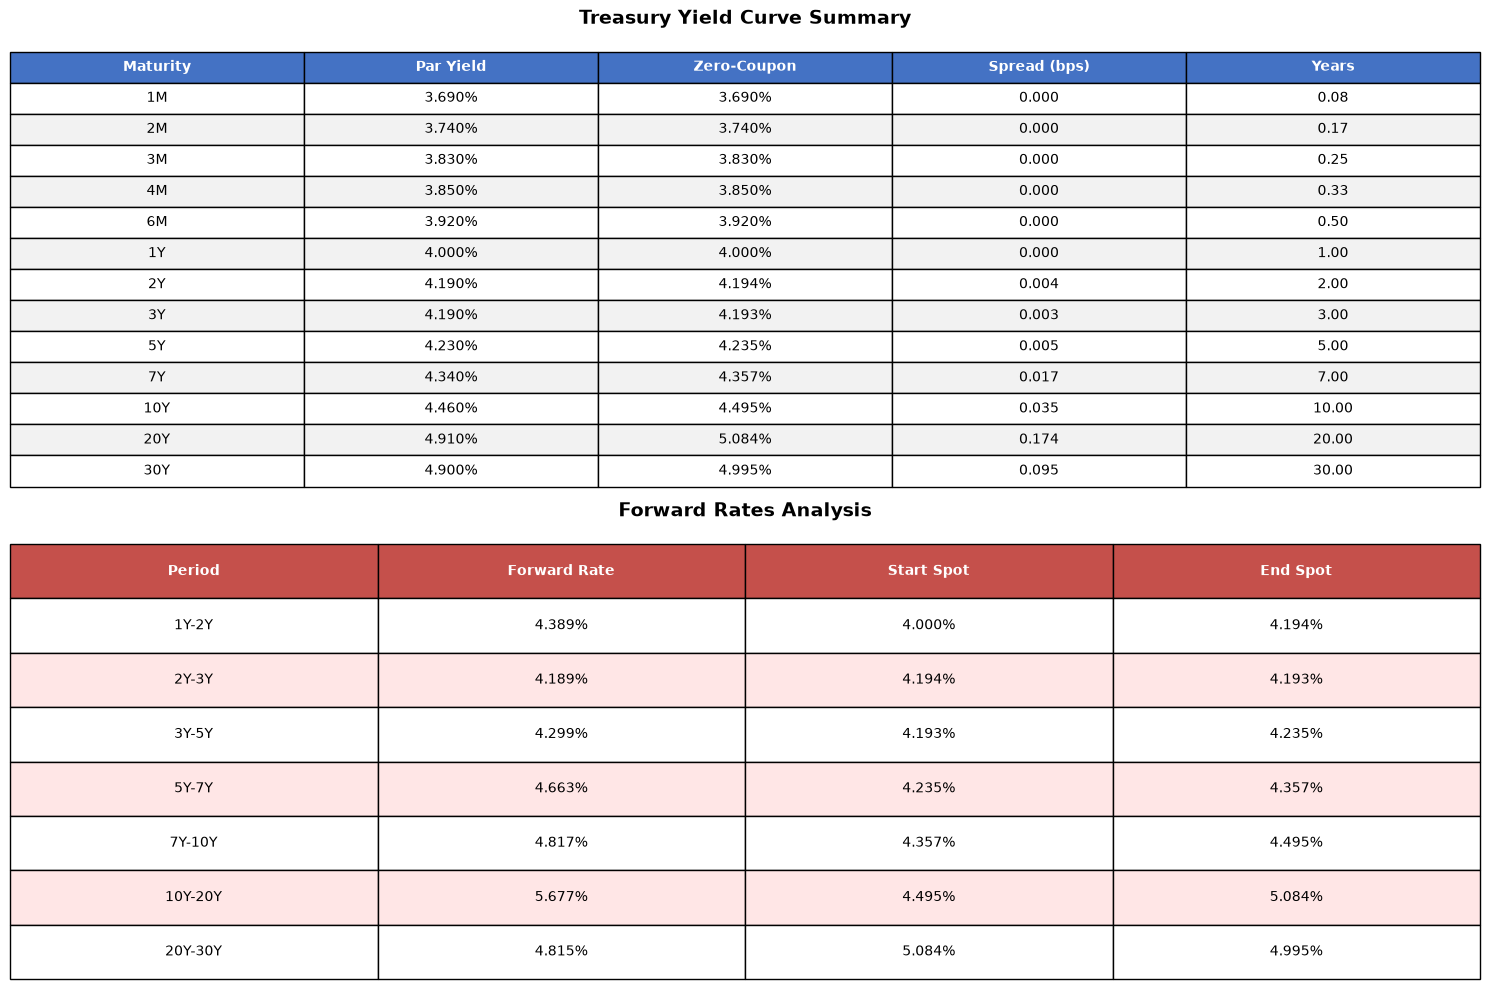

In [5]:
plot_yield_curves(curve_with_zero, " - Treasury XML Data")
plt.show()

plot_forward_rates(fwd, curve_with_zero)
plt.show()

create_summary_table(curve_with_zero, fwd)
plt.show()


## Curve shape analysis

In [6]:
two_year = curve_with_zero.loc[curve_with_zero['maturity_label'] == '2Y', 'par_yield'].iloc[0]
ten_year = curve_with_zero.loc[curve_with_zero['maturity_label'] == '10Y', 'par_yield'].iloc[0]
thirty_year = curve_with_zero.loc[curve_with_zero['maturity_label'] == '30Y', 'par_yield'].iloc[0]

two_ten_spread = ten_year - two_year
ten_thirty_spread = thirty_year - ten_year

if two_ten_spread < -0.1:
    shape = "Inverted"
elif two_ten_spread < 0.1:
    shape = "Flat"
else:
    shape = "Normal"

print(f"Curve shape: {shape}")
print(f"2Y-10Y spread: {two_ten_spread:.3f}% ({two_ten_spread * 100:.1f} bps)")
print(f"10Y-30Y spread: {ten_thirty_spread:.3f}% ({ten_thirty_spread * 100:.1f} bps)")

max_row = curve_with_zero.loc[curve_with_zero['par_yield'].idxmax()]
min_row = curve_with_zero.loc[curve_with_zero['par_yield'].idxmin()]
print(f"\nHighest yield: {max_row['par_yield']:.3f}% ({max_row['maturity_label']})")
print(f"Lowest yield: {min_row['par_yield']:.3f}% ({min_row['maturity_label']})")

if not fwd.empty:
    max_fwd = fwd.loc[fwd['forward_rate'].idxmax()]
    min_fwd = fwd.loc[fwd['forward_rate'].idxmin()]
    print(f"\nHighest forward rate: {max_fwd['forward_rate']:.3f}% ({max_fwd['period']})")
    print(f"Lowest forward rate: {min_fwd['forward_rate']:.3f}% ({min_fwd['period']})")

    avg_forward = fwd['forward_rate'].mean()
    avg_spot = curve_with_zero['zero_coupon_yield'].mean()
    direction = "rising" if avg_forward > avg_spot else "falling"
    print(
        f"\nAverage forward rate ({avg_forward:.3f}%) vs average spot rate "
        f"({avg_spot:.3f}%) -> market implies {direction} rates"
    )


Curve shape: Normal
2Y-10Y spread: 0.270% (27.0 bps)
10Y-30Y spread: 0.440% (44.0 bps)

Highest yield: 4.910% (20Y)
Lowest yield: 3.690% (1M)

Highest forward rate: 5.677% (10Y-20Y)
Lowest forward rate: 4.189% (2Y-3Y)

Average forward rate (4.693%) vs average spot rate (4.199%) -> market implies rising rates
